### Import dependencies

In [ ]:
# import gwpy as gw
import oreonspy as op
import numpy as np
import matplotlib.pyplot as plt
import oreonspy.utils as ut

import os

In [2]:
op.__version__

'4.4.2'

In [ ]:
# LASER
E_in_avg = 1  #
lambd = 1064e-9  # m
# k = 2.*np.pi / lambd

In [ ]:
# Creating of the name list of the files in the folder tests/optical_cavities_testset
file_names = [
    file_name
    for file_name in os.listdir("../tests/optical_cavities_testset")
    if file_name.endswith(".xml")
]

print(f"Nomi dei file trovati: {file_names}")

Nomi dei file trovati: ['cavity_14397bf2-8fe3-5c85-811d-053248fff88c.xml', 'cavity_1a61c87f-5715-5ad7-b68d-291ce4be6cfb.xml', 'cavity_7d9a4874-1582-586f-899b-814c287a71df.xml', 'cavity_d04053d2-4a5e-5b90-a32e-381f745a3cb4.xml', 'cavity_44775a16-eade-5508-8790-40517bc6c5cb.xml', 'cavity_2cabab7b-02e7-5ccc-9f53-12299da99724.xml', 'cavity_ee83efce-96ca-54e4-9016-1496c05c3a46.xml', 'cavity_1b834b5a-a64d-521b-82c6-a09751fc4817.xml', 'cavity_c04207c3-fc1d-5a10-87fb-adb6b33e7aa4.xml', 'cavity_9091728a-dfbc-504b-abc7-990f30cfde82.xml', 'cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', 'cavity_c0ce476c-359b-5592-bdaa-8ba1797af58d.xml', 'cavity_4ca5ed57-c6d0-54ae-8b16-903b27cac8c8.xml', 'cavity_cbd7f5db-a267-57eb-8a47-4ecf81e9e2c3.xml', 'cavity_0c4b9c47-5b22-5678-9107-511887fa03d8.xml', 'cavity_142ab657-b670-55ad-9420-1838a153873b.xml', 'cavity_87ea86c6-0db4-578b-ba3e-fdc56a3749a6.xml', 'cavity_faab30cb-7f62-543b-9bf5-039f59622142.xml', 'cavity_f34546f2-cb22-540f-88a9-dbd0033e1ecb.xml', 'cavity

In [ ]:
# Extracting the list of file paths
file_paths = [
    os.path.join("../tests/optical_cavities_testset", file_name)
    for file_name in file_names
]

print(f"File paths trovati: {file_paths}")

File paths trovati: ['../tests/optical_cavities_testset/cavity_14397bf2-8fe3-5c85-811d-053248fff88c.xml', '../tests/optical_cavities_testset/cavity_1a61c87f-5715-5ad7-b68d-291ce4be6cfb.xml', '../tests/optical_cavities_testset/cavity_7d9a4874-1582-586f-899b-814c287a71df.xml', '../tests/optical_cavities_testset/cavity_d04053d2-4a5e-5b90-a32e-381f745a3cb4.xml', '../tests/optical_cavities_testset/cavity_44775a16-eade-5508-8790-40517bc6c5cb.xml', '../tests/optical_cavities_testset/cavity_2cabab7b-02e7-5ccc-9f53-12299da99724.xml', '../tests/optical_cavities_testset/cavity_ee83efce-96ca-54e4-9016-1496c05c3a46.xml', '../tests/optical_cavities_testset/cavity_1b834b5a-a64d-521b-82c6-a09751fc4817.xml', '../tests/optical_cavities_testset/cavity_c04207c3-fc1d-5a10-87fb-adb6b33e7aa4.xml', '../tests/optical_cavities_testset/cavity_9091728a-dfbc-504b-abc7-990f30cfde82.xml', '../tests/optical_cavities_testset/cavity_4469917c-b658-568e-9f45-5155da41ee3a.xml', '../tests/optical_cavities_testset/cavity_c0

In [ ]:
# Extracting the list of the UUIDs from the file names
UUIDS = []
for file_name in file_names:
    uuid = file_name.split("_")[1].split(".")[0]
    UUIDS.append(uuid)
print(len(UUIDS))

99


In [ ]:
import xml.etree.ElementTree as ET

# Path of the XML file
file_path = "../tests/optical_cavities.xml"

# Parsing of the XML file
tree = ET.parse(file_path)
root = tree.getroot()

# List to store UUIDs of the cavities to load
UUIDS_to_load = []

# Extracting the wanted UUIDs from the XML file
for cavity in root.findall("Cavity"):
    uuid_element = cavity.find("UUID")
    if uuid_element is not None:
        UUIDS_to_load.append(uuid_element.text)

# Printing the UUIDs to load
print(f"All UUIDs found: {len(UUIDS_to_load)}")

All UUIDs found: 99


In [ ]:
# Filter and parse cavities with UUIDs present in UUIDS
filtered_cavities = []
filtered_UUIDS = []

for file_path in file_paths:
    cavity = op.Cavity()
    uuid = file_name.split("_")[1].split(".")[0]
    if uuid in UUIDS_to_load:
        filtered_UUIDS.append(uuid)
        cavity.xml_load(file_path)
        filtered_cavities.append(cavity)

# Select one cavity every five
selected_cavities = filtered_cavities[::5]
selected_UUIDS = filtered_UUIDS[::5]
print(f"Selected {len(selected_cavities)} cavities from the filtered list.")

Selected 20 cavities from the filtered list.


In [11]:
print(selected_cavities[0])
print(selected_UUIDS[0])

b71f3c26-1518-51fc-a859-fed711d81b8e


In [12]:
cavity = selected_cavities[0]

In [ ]:
cavity.print_params()
v_cr = ut.critical_velocity(
    cavity, wavelength=ut.lambd, L=cavity.params.cavity_length, Finesse=cavity.Finesse()
)
velocity_factor = 5
f_calc = ut.optimal_sampling_frequency(
    cavity=cavity, critical_velocity_factor=velocity_factor
)
print(f"Critical velocity: {v_cr}")
print(f"Optimal sampling frequency: {f_calc}")

t_a: 0.014
r_a: 0.9897565518195881
r_b: 0.9897565518195881
cavity_length: 319.169
Critical velocity: 3.372559001778674e-05
Optimal sampling frequency: 292762.28718356066


In [ ]:
# LASER
E_in_avg = 1.0 + 0.0j  #


def generate_cavity_evolution(
    cavity, z_evolution, E_evolution, num_points, time_steps, title=None
):
    results = np.zeros(num_points, dtype=np.complex128)

    z_evolution = np.append(z_evolution, z_evolution[-1])

    results[0], _ = cavity.sim_step(
        input_electric_field=E_evolution[0], output_mirror_displacement=0.0
    )
    for t in range(num_points - 1):
        d_zeta = z_evolution[t + 1] - z_evolution[t]
        results[t + 1], _ = cavity.sim_step(
            E_evolution[t],
            output_mirror_displacement=d_zeta,
        )

    s = np.abs(results) ** 2
    ph = np.angle(results)
    pdh = ut.V_pdh(0.0, E_evolution, results)

    print(f"Results for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz:")
    # print(results)

    simple_plot = False
    if simple_plot is False:
        ut.plot_cavity_evolution(
            output_mirror_displacements=z_evolution,
            input_electric_field=E_evolution,
            intracav_electric_field=results,
            pdh=pdh,
            file_name=title,
        )
    else:
        plt.plot(time_steps, s)
        plt.plot(time_steps, ph)
        plt.plot(time_steps, pdh)
        plt.xlabel("Time (s)")
        plt.ylabel("Cavity Evolution")
        plt.title(
            f"Cavity Evolution for v = {velocity_factor} v_cr and f_calc = {f_calc} Hz"
        )
        plt.show()
    return s, ph, pdh

wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 292762.28718356066
initial_input_electric_field: (1+0j)
sampling_frequency: 234822.6629152581
num_roundtrips: 2
Theta: 4.258532748011959e-06
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 0.8020932790705564
[0.00000000e+00 7.18433491e-10 1.43686698e-09 ... 1.06256313e-06
 1.06328157e-06 1.06400000e-06]
Results for v = 5 v_cr and f_calc = 234822.6629152581 Hz:


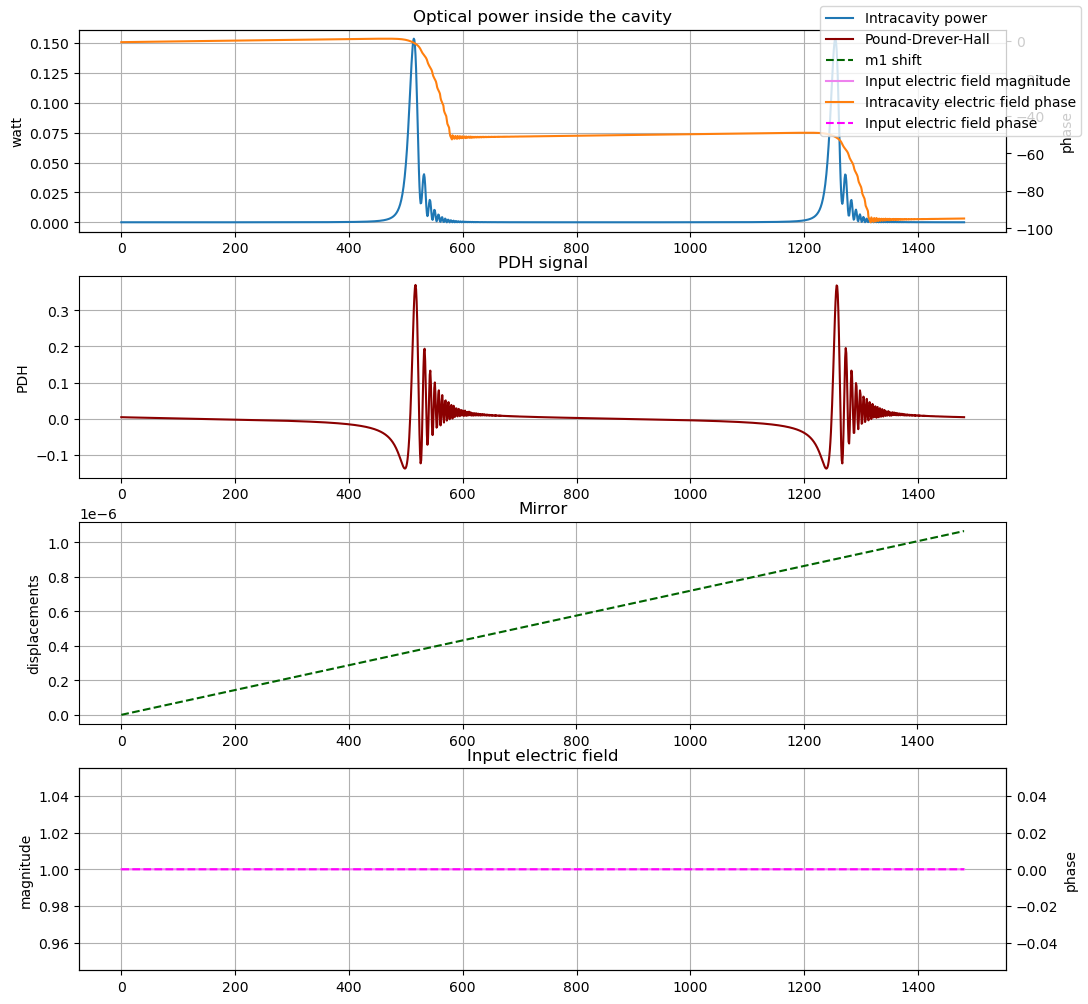

In [ ]:
# Define velocities and f_calc range
# velocity_factors = np.array([0.1, 1, 2, 5, 10])
# frequency_factors = np.array([1, 3, 10])

cavity.simulation(lambd, f_calc, E_in_avg)
cavity.print_sim_params()
f_calc = cavity.sim_params.sampling_frequency

num_points, time_steps = ut.generate_time_points_for_constant_velocity(
    velocity=v_cr * velocity_factor, f_calc=f_calc
)
E_ev = np.ones(num_points)

z_ev = np.linspace(0.0, ut.lambd, num_points)
print(z_ev)

s, ph, pdh = generate_cavity_evolution(cavity, z_ev, E_ev, num_points, time_steps)

### Simulatng with low frequency

In [ ]:
# Filter and parse cavities with UUIDs present in UUIDS
filtered_cavities1 = []
filtered_UUIDS = []

for file_path in file_paths:
    cavity1 = op.Cavity()
    uuid = file_name.split("_")[1].split(".")[0]
    if uuid in UUIDS_to_load:
        filtered_UUIDS.append(uuid)
        cavity1.xml_load(file_path)
        filtered_cavities1.append(cavity)

# Select one cavity every five
selected_cavities = filtered_cavities1[::5]
selected_UUIDS = filtered_UUIDS[::5]
print(f"Selected {len(selected_cavities)} cavities from the filtered list.")

Selected 20 cavities from the filtered list.


wave_number: 5905249.348852994
k2j: -11810498.697705988j
requested_sampling_frequency: 23482.266291525808
initial_input_electric_field: (1+0j)
sampling_frequency: 23482.266291525808
num_roundtrips: 20
Theta: 4.2585327480119594e-05
partial_Theta: False
Theta_fraction: 1.0
num_of_subhist: 1
sampling_frequency_accuracy: 1.0
149
Results for v = 5 v_cr and f_calc = 234822.6629152581 Hz:


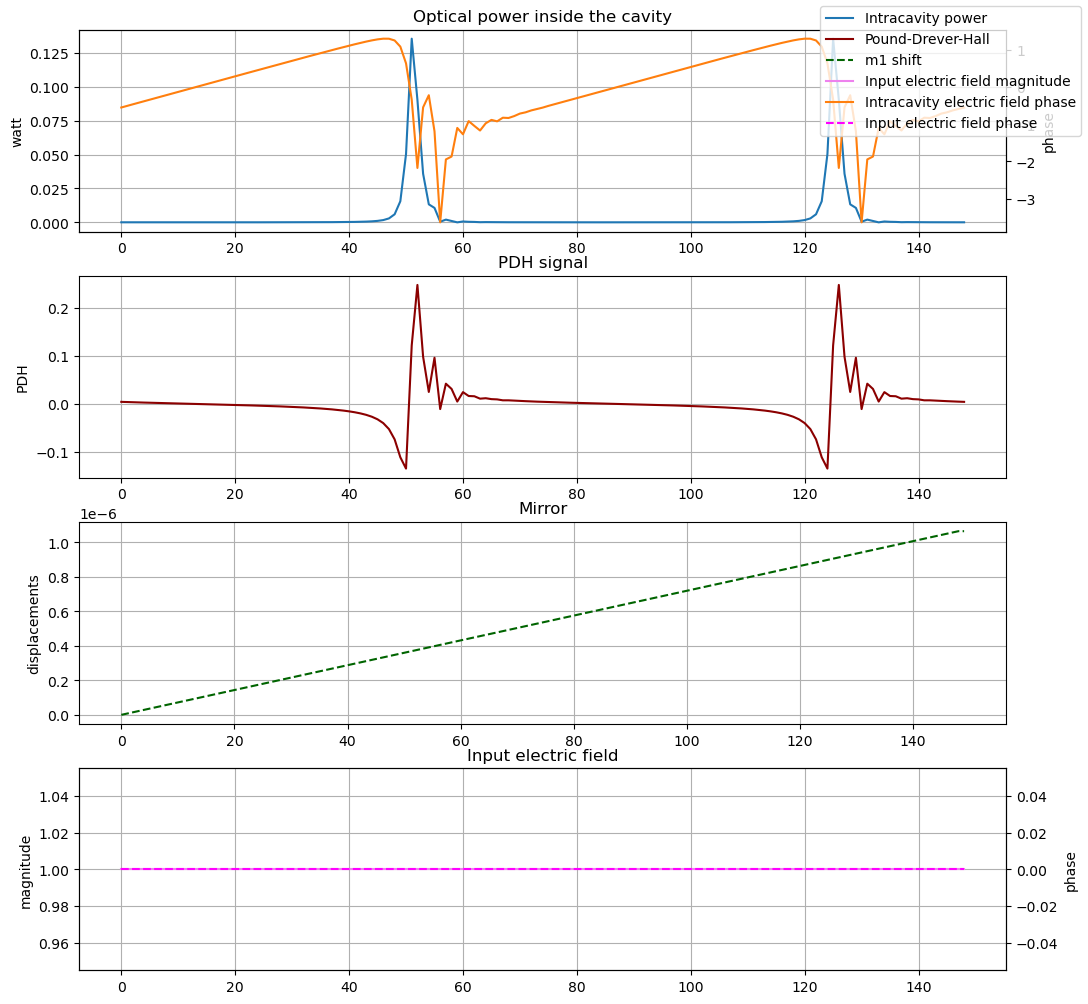

In [ ]:
f_low = f_calc / 10

cavity1 = selected_cavities[0]

cavity1.simulation(lambd, f_low, E_in_avg)
cavity1.print_sim_params()
f_low = cavity1.sim_params.sampling_frequency

num_points, time_steps_low = ut.generate_time_points_for_constant_velocity(
    velocity=v_cr * velocity_factor, f_calc=f_low
)
print(num_points)

E_ev = np.ones(num_points)

z_ev_low = np.linspace(0.0, ut.lambd, num_points)

s_low, ph_low, pdh_low = generate_cavity_evolution(
    cavity1, z_ev_low, E_ev, num_points, time_steps_low
)

### Resampling of the time series and plotting

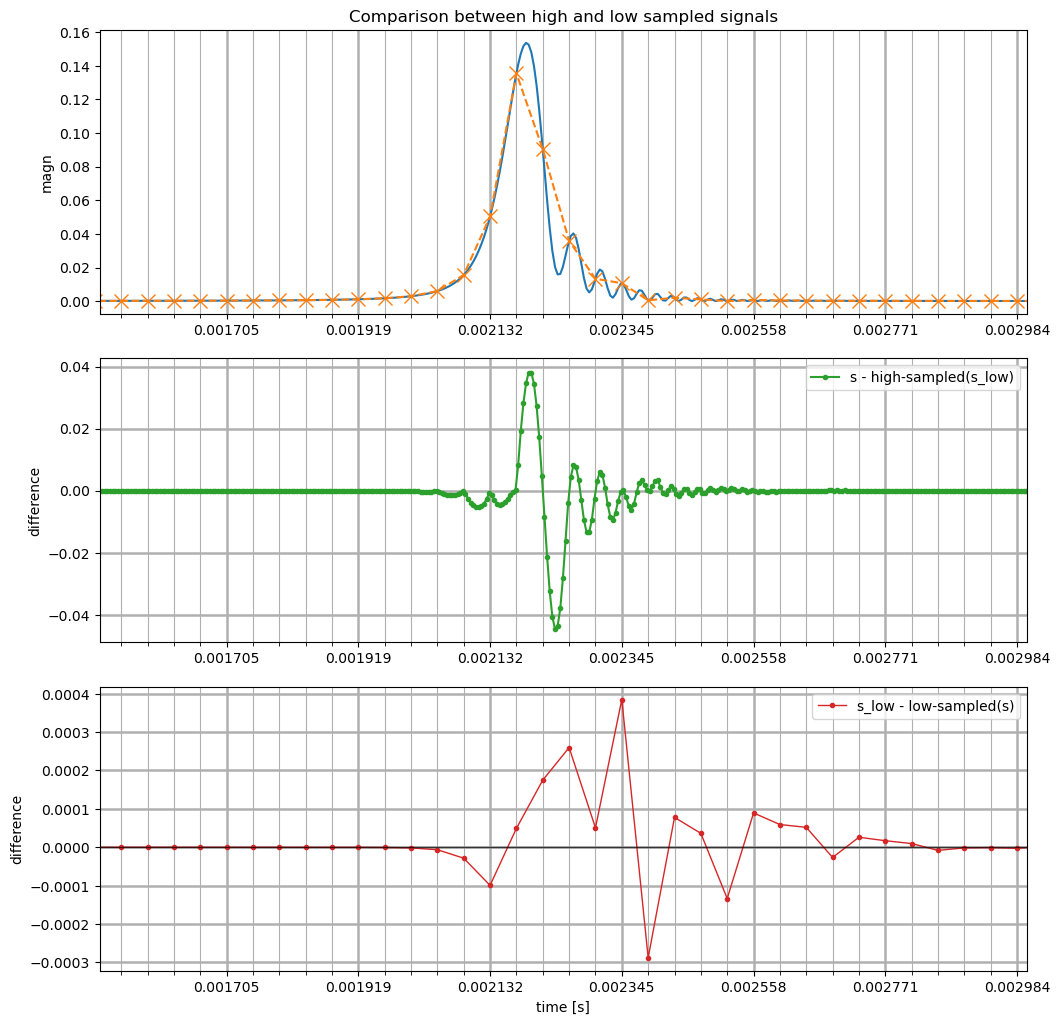

In [63]:
from matplotlib.ticker import MultipleLocator

# Time windowd for zooming in
x_start = 0.0015
x_stop = 0.003

major_step = time_steps_low[5] - time_steps_low[0]
minor_step = major_step / 5

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
fig.tight_layout()
ax[0].plot(time_steps, s, label="High sampled")
ax[0].xaxis.set_major_locator(MultipleLocator(major_step))
ax[0].xaxis.set_minor_locator(MultipleLocator(minor_step))
ax[0].tick_params(axis="x", which="minor", length=3, rotation=45)
ax[0].grid(which="both", axis="x")
ax[0].grid(which="major", axis="x", linewidth=1.8)
ax[0].set_ylabel("magn")
ax[0].title.set_text("Comparison between high and low sampled signals")
ax[0].set_xlim(x_start, x_stop)

ax[0].plot(
    time_steps_low,
    s_low,
    label="low_sampled",
    color="tab:orange",
    linestyle="--",
    marker="x",
    markersize=10,
)
ax[0].tick_params(axis="y")

# Resample low-sampled signal on the high-sampled time grid
s_low_resampled = np.interp(time_steps, time_steps_low, s_low)

# High-sampled signal minus interpolated low-sampled signal on the middle pane
diff = s - s_low_resampled
ax[1].plot(
    time_steps,
    diff,
    color="tab:green",
    marker="o",
    markersize=3,
    label="s - high-sampled(s_low)",
)
ax[1].xaxis.set_major_locator(MultipleLocator(major_step))
ax[1].xaxis.set_minor_locator(MultipleLocator(minor_step))
ax[1].tick_params(axis="x", which="minor", length=3, rotation=45)
ax[1].grid(which="both", axis="x")
ax[1].grid(which="major", axis="both", linewidth=1.8)
ax[1].set_ylabel("difference")
ax[1].set_xlim(x_start, x_stop)
ax[1].legend(loc="best")

# Low-sampled signal minus high-sampled signal evaluated at low-sample times on the lower pane
s_on_low_grid = np.interp(time_steps_low, time_steps, s)
diff_low_grid = s_low - s_on_low_grid

ax[2].plot(
    time_steps_low,
    diff_low_grid,
    color="tab:red",
    marker="o",
    markersize=3,
    linewidth=1,
    label="s_low - low-sampled(s)",
)
ax[2].axhline(0.0, color="k", linewidth=1, alpha=0.7)
ax[2].xaxis.set_major_locator(MultipleLocator(major_step))
ax[2].xaxis.set_minor_locator(MultipleLocator(minor_step))
ax[2].tick_params(axis="x", which="minor", length=3, rotation=45)
ax[2].grid(which="both", axis="x")
ax[2].grid(which="major", axis="both", linewidth=1.8)
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("difference")
ax[2].set_xlim(x_start, x_stop)
ax[2].legend(loc="best")

plt.show()